In [ ]:
# Install interactive BI & visualization libraries for Google Colab
!pip install -q plotly pygwalker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.2/956.2 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 73.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files

# Global theme setup
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

print("Upload your Clinical Heart Disease Dataset (.csv or .xlsx):")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Flexible dataset reader
df = pd.read_csv(io.BytesIO(uploaded[file_name])) if file_name.endswith('.csv') else pd.read_excel(io.BytesIO(uploaded[file_name]))

# Standardize column headers
df.columns = df.columns.str.strip().str.lower()

# Numeric conversions
numeric_targets = ['age', 'cholesterol (mg/dl)', 'bmi', 'heart rate', 'glucose (mg/dl)', 'systolic b.p.(mm_hg)', 'diastolic b.p.(mm_hg)']
for col in df.columns:
    if any(metric in col for metric in ['age', 'cholesterol', 'bmi', 'heart rate', 'glucose', 'systolic', 'diastolic']):
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Feature Engineering: Clinical Stratifications
if 'bmi' in df.columns:
    df['bmi_category'] = pd.cut(
        df['bmi'],
        bins=[0, 18.5, 24.9, 29.9, 100],
        labels=['Underweight', 'Normal', 'Overweight', 'Obese']
    )

# Stratify Blood Pressure Stage according to AHA guidelines
def stratify_bp(row):
    sys_col = [c for c in df.columns if 'systolic' in c]
    dia_col = [c for c in df.columns if 'diastolic' in c]
    if not sys_col or not dia_col: return np.nan
    sys, dia = row[sys_col[0]], row[dia_col[0]]
    if pd.isna(sys) or pd.isna(dia): return np.nan
    if sys < 120 and dia < 80: return 'Normal'
    elif 120 <= sys <= 129 and dia < 80: return 'Elevated'
    elif 130 <= sys <= 139 or 80 <= dia <= 89: return 'Stage 1 Hypertension'
    else: return 'Stage 2 Hypertension'

df['bp_stage'] = df.apply(stratify_bp, axis=1)

print(f"\nSuccessfully Processed: {df.shape[0]} Patient Records | {df.shape[1]} Clinical Attributes")
df.head()

Upload your Clinical Heart Disease Dataset (.csv or .xlsx):


Saving Dataset.csv to Dataset.csv

Successfully Processed: 1004 Patient Records | 21 Clinical Attributes


,patient_id,age,gender,cholesterol (mg/dl),bmi,heart rate,glucose (mg/dl),systolic b.p.(mm_hg),diastolic b.p.(mm_hg),resting ecg result,...,unnamed: 11,unnamed: 12,unnamed: 13,unnamed: 14,unnamed: 15,unnamed: 16,unnamed: 17,unnamed: 18,bmi_category,bp_stage
0,1.0,19.0,Male,198.0,22.1,72.0,88.0,115.0,75.0,Normal sinus rhythm,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,Normal
1,2.0,34.0,Female,233.0,24.3,65.0,98.0,120.0,78.0,Sinus bradycardia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,Elevated
2,3.0,58.0,Male,210.0,19.6,84.0,102.0,125.0,80.0,Normal sinus rhythm,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,Stage 1 Hypertension
3,4.0,83.0,Female,194.0,28.2,78.0,96.0,125.0,82.0,Left bundle branch block,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Overweight,Stage 1 Hypertension
4,5.0,21.0,Male,187.0,20.9,73.0,90.0,115.0,75.0,Normal sinus rhythm,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal,Normal


In [ ]:
# Executive Clinical KPI Scorecard
total_patients = len(df)
chol_col = [c for c in df.columns if 'cholesterol' in c]
gluc_col = [c for c in df.columns if 'glucose' in c]
sys_col = [c for c in df.columns if 'systolic' in c]
bmi_col = [c for c in df.columns if 'bmi' in c]

avg_chol = df[chol_col[0]].mean() if chol_col else np.nan
avg_glucose = df[gluc_col[0]].mean() if gluc_col else np.nan
avg_sys_bp = df[sys_col[0]].mean() if sys_col else np.nan
pct_high_risk_bp = (df['bp_stage'].isin(['Stage 1 Hypertension', 'Stage 2 Hypertension'])).mean() * 100 if 'bp_stage' in df.columns else np.nan

kpi_dashboard = pd.DataFrame({
    'Clinical Indicator Metric': [
        'Total Cohort Patients',
        'Mean Serum Cholesterol (mg/dL)',
        'Mean Fasting Glucose (mg/dL)',
        'Mean Systolic BP (mmHg)',
        'Hypertensive Cohort Share (%)'
    ],
    'Value': [
        f"{total_patients:,}",
        f"{avg_chol:.1f} mg/dL" if pd.notna(avg_chol) else "N/A",
        f"{avg_glucose:.1f} mg/dL" if pd.notna(avg_glucose) else "N/A",
        f"{avg_sys_bp:.1f} mmHg" if pd.notna(avg_sys_bp) else "N/A",
        f"{pct_high_risk_bp:.1f}%" if pd.notna(pct_high_risk_bp) else "N/A"
    ]
})

print("=== EXECUTIVE CLINICAL METRIC DASHBOARD ===")
kpi_dashboard

=== EXECUTIVE CLINICAL METRIC DASHBOARD ===


,Clinical Indicator Metric,Value
0,Total Cohort Patients,"1,004"
1,Mean Serum Cholesterol (mg/dL),214.6 mg/dL
2,Mean Fasting Glucose (mg/dL),105.6 mg/dL
3,Mean Systolic BP (mmHg),126.6 mmHg
4,Hypertensive Cohort Share (%),64.4%


/tmp/ipykernel_1153/3415521760.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix_data = df.pivot_table(


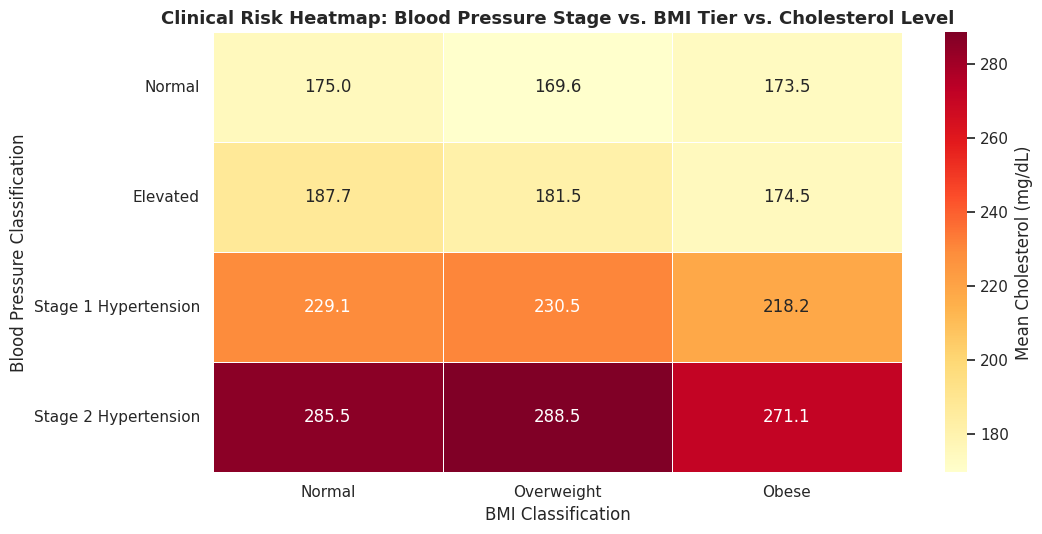

In [ ]:
# 1. Power BI Style Heatmap Matrix: Blood Pressure Stages vs. BMI Categories vs. Mean Cholesterol
import seaborn as sns
import matplotlib.pyplot as plt

if 'bp_stage' in df.columns and 'bmi_category' in df.columns and chol_col:
    bp_order = ['Normal', 'Elevated', 'Stage 1 Hypertension', 'Stage 2 Hypertension']
    matrix_data = df.pivot_table(
        index='bp_stage',
        columns='bmi_category',
        values=chol_col[0],
        aggfunc='mean'
    ).reindex(bp_order)

    plt.figure(figsize=(11, 5.5))
    sns.heatmap(matrix_data, cmap='YlOrRd', annot=True, fmt='.1f', linewidths=0.5, cbar_kws={'label': 'Mean Cholesterol (mg/dL)'})
    plt.title('Clinical Risk Heatmap: Blood Pressure Stage vs. BMI Tier vs. Cholesterol Level', fontweight='bold', fontsize=13)
    plt.xlabel('BMI Classification')
    plt.ylabel('Blood Pressure Classification')
    plt.tight_layout()
    plt.show()

In [ ]:
# 2. 4D Interactive Biomarker Map (Age vs. Cholesterol vs. Glucose vs. BMI)
import plotly.express as px

if all([chol_col, gluc_col, 'age']):
    fig_4d = px.scatter(
        df,
        x=chol_col[0],
        y=gluc_col[0],
        size='bmi' if 'bmi' in df.columns else None,
        color='gender' if 'gender' in df.columns else None,
        hover_data=['age', 'bp_stage'] if 'bp_stage' in df.columns else ['age'],
        title="<b>4D Clinical Biomarker Distribution: Cholesterol vs. Glucose vs. BMI (Node Size)</b>",
        labels={chol_col[0]: "Cholesterol (mg/dL)", gluc_col[0]: "Glucose (mg/dL)"},
        template="plotly_white",
        color_discrete_sequence=px.colors.qualitative.Set1
    )
    fig_4d.update_layout(height=600)
    fig_4d.show()

In [ ]:
# Fixed Tableau-Style Hierarchical Patient Stratification Sunburst
import plotly.express as px

hierarchy_cols = [c for c in ['gender', 'bmi_category', 'bp_stage', 'resting ecg result'] if c in df.columns]

if len(hierarchy_cols) >= 3:
    # 1. Drop rows with missing values in the hierarchy path to prevent non-leaf node errors
    df_sunburst = df.dropna(subset=hierarchy_cols).copy()

    # 2. Ensure all hierarchy elements are cast to standard strings
    for col in hierarchy_cols:
        df_sunburst[col] = df_sunburst[col].astype(str)

    # 3. Render Sunburst chart safely
    fig_sunburst = px.sunburst(
        df_sunburst,
        path=hierarchy_cols,
        values=chol_col[0] if (chol_col and chol_col[0] in df_sunburst.columns) else None,
        color=hierarchy_cols[0],
        title='<b>Hierarchical Patient Stratification (Gender → BMI Tier → BP Stage → ECG Result)</b>',
        template='plotly_white'
    )
    fig_sunburst.update_layout(height=650)
    fig_sunburst.show()
else:
    print("Insufficient hierarchy columns found in dataset to render Sunburst chart.")

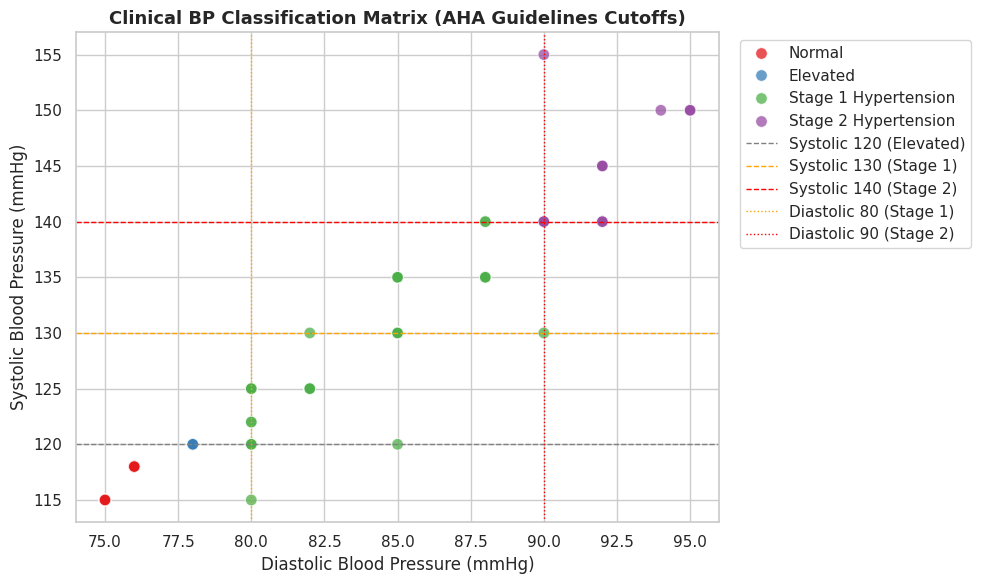

In [9]:
# 1. AHA Blood Pressure Diagnostic Quadrant Matrix (Systolic vs. Diastolic with Clinical Thresholds)
import matplotlib.pyplot as plt
import seaborn as sns

sys_col = [c for c in df.columns if 'systolic' in c]
dia_col = [c for c in df.columns if 'diastolic' in c]

if sys_col and dia_col:
    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x=dia_col[0],
        y=sys_col[0],
        hue='bp_stage' if 'bp_stage' in df.columns else None,
        palette='Set1',
        alpha=0.75,
        s=70
    )

    # AHA Threshold Guideline Lines
    plt.axhline(y=120, color='gray', linestyle='--', linewidth=1, label='Systolic 120 (Elevated)')
    plt.axhline(y=130, color='orange', linestyle='--', linewidth=1, label='Systolic 130 (Stage 1)')
    plt.axhline(y=140, color='red', linestyle='--', linewidth=1, label='Systolic 140 (Stage 2)')
    plt.axvline(x=80, color='orange', linestyle=':', linewidth=1, label='Diastolic 80 (Stage 1)')
    plt.axvline(x=90, color='red', linestyle=':', linewidth=1, label='Diastolic 90 (Stage 2)')

    plt.title('Clinical BP Classification Matrix (AHA Guidelines Cutoffs)', fontweight='bold', fontsize=13)
    plt.xlabel('Diastolic Blood Pressure (mmHg)')
    plt.ylabel('Systolic Blood Pressure (mmHg)')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [10]:
# 2. 3D Clinical Risk Space: Age vs. Systolic BP vs. Cholesterol
import plotly.express as px

chol_col = [c for c in df.columns if 'cholesterol' in c]
sys_col = [c for c in df.columns if 'systolic' in c]

if all([chol_col, sys_col, 'age' in df.columns]):
    fig_3d = px.scatter_3d(
        df.dropna(subset=['age', sys_col[0], chol_col[0]]),
        x='age',
        y=sys_col[0],
        z=chol_col[0],
        color='bp_stage' if 'bp_stage' in df.columns else None,
        size='bmi' if 'bmi' in df.columns else None,
        hover_data=['gender', 'glucose (mg/dl)'] if 'glucose (mg/dl)' in df.columns else ['gender'],
        opacity=0.8,
        title='<b>3D Risk Trajectory: Age vs. Systolic BP vs. Cholesterol Level</b>',
        labels={'age': 'Age (Years)', sys_col[0]: 'Systolic BP (mmHg)', chol_col[0]: 'Cholesterol (mg/dL)'},
        template='plotly_white'
    )
    fig_3d.update_layout(height=700)
    fig_3d.show()

In [11]:
# 3. Patient Clinical Trajectory Risk Flow (Sankey Diagram)
import plotly.graph_objects as go
import pandas as pd

sankey_cols = [c for c in ['gender', 'bmi_category', 'bp_stage'] if c in df.columns]

if len(sankey_cols) == 3:
    df_sankey = df.dropna(subset=sankey_cols).copy()
    for c in sankey_cols:
        df_sankey[c] = df_sankey[c].astype(str)

    # Unique nodes across categories
    nodes = list(pd.unique(df_sankey[sankey_cols].values.ravel()))
    node_dict = {node: i for i, node in enumerate(nodes)}

    # Link 1: Gender -> BMI Category
    l1 = df_sankey.groupby([sankey_cols[0], sankey_cols[1]]).size().reset_index(name='value')
    l1['source'] = l1[sankey_cols[0]].map(node_dict)
    l1['target'] = l1[sankey_cols[1]].map(node_dict)

    # Link 2: BMI Category -> BP Stage
    l2 = df_sankey.groupby([sankey_cols[1], sankey_cols[2]]).size().reset_index(name='value')
    l2['source'] = l2[sankey_cols[1]].map(node_dict)
    l2['target'] = l2[sankey_cols[2]].map(node_dict)

    links = pd.concat([l1[['source', 'target', 'value']], l2[['source', 'target', 'value']]])

    fig_sankey = go.Figure(data=[go.Sankey(
        node=dict(pad=15, thickness=20, line=dict(color="black", width=0.5), label=nodes),
        link=dict(source=links['source'], target=links['target'], value=links['value'], color='rgba(231, 76, 60, 0.3)')
    )])

    fig_sankey.update_layout(
        title_text="<b>Patient Risk Pipeline (Gender → BMI Category → BP Stage)</b>",
        template="plotly_white",
        height=550
    )
    fig_sankey.show()

In [13]:
# Fixed Normalized Biomarker Spider / Radar Profile by Blood Pressure Stage
from sklearn.preprocessing import MinMaxScaler
import plotly.graph_objects as go
import numpy as np

# Select strictly numeric columns matching biomarkers (excludes string columns like 'bmi_category')
numeric_cols = df.select_dtypes(include=[np.number]).columns
bio_metrics = [c for c in numeric_cols if any(m in c.lower() for m in ['cholesterol', 'bmi', 'heart rate', 'glucose', 'systolic', 'diastolic'])]

if len(bio_metrics) >= 3 and 'bp_stage' in df.columns:
    df_radar_raw = df.dropna(subset=bio_metrics + ['bp_stage']).copy()

    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_radar_raw[bio_metrics]), columns=bio_metrics)
    df_scaled['bp_stage'] = df_radar_raw['bp_stage'].values

    radar_summary = df_scaled.groupby('bp_stage').mean().T.reset_index()

    fig_radar = go.Figure()
    for stage in radar_summary.columns[1:]:
        fig_radar.add_trace(go.Scatterpolar(
            r=radar_summary[stage],
            theta=radar_summary['index'],
            fill='toself',
            name=str(stage)
        ))

    fig_radar.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        title='<b>Normalized Clinical Radar Profile across BP Stages</b>',
        template='plotly_white',
        height=500
    )
    fig_radar.show()
else:
    print("Insufficient numeric biomarker columns or missing 'bp_stage' column.")

In [14]:
# 5. Multi-Biomarker Parallel Coordinates Profile
import plotly.express as px

parallel_cols = [c for c in df.columns if any(m in c for m in ['age', 'bmi', 'cholesterol', 'glucose', 'systolic'])]

if len(parallel_cols) >= 4:
    fig_parallel = px.parallel_coordinates(
        df.dropna(subset=parallel_cols),
        dimensions=parallel_cols,
        color=sys_col[0] if sys_col else parallel_cols[0],
        color_continuous_scale=px.colors.sequential.Reds,
        title='<b>Multi-Biomarker Parallel Trajectory Profile</b>',
        template='plotly_white'
    )
    fig_parallel.update_layout(height=500)
    fig_parallel.show()